# Imports

In [1]:
import pickle
import pickletools
import datetime
from eolearn.core import EOPatch
from pyproj import Proj, transform

import numpy as np
import pandas as pd

import geopandas as gpd
import rasterio as rio
from rasterio import features

from patchify import patchify

import torch


# Device Configuration

In [9]:
DEVICE  = torch.device(f"cuda:0" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda:0


# Constants

- Sentinel 2 Bands information
-------------------------------
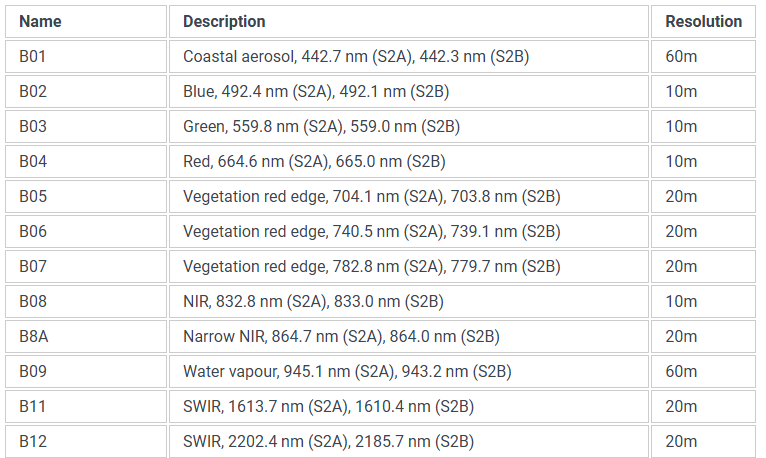

In [ ]:
BANDS = ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B11","B12"]
BAND_CLASSES = ["COSTAL_AEROSOL", "BLUE", "GREEN", "RED",
                "VEGETATION_RED_EDGE-704NM", "VEGETATION_RED_EDGE-740NM",
                "VEGETATION_RED_EDGE-782NM", "NIR","NARROW_NIR", "WATER_VAPOUR",
                "SWIR-1612NM","SWIR-2202NM"]

CROP_CLASSES = ["Wheat", "Rye", "Barley", "Oats", "Corn", "Oil Seeds", "Root Crops",
                "Meadows", "Forage Crops"]
CROP_IDS = [1, 2, 3, 4, 5, 6, 7, 8, 9]


# Data Pre-processing

## Understanding Data

### Helper functions

In [ ]:
def formatCordinates(cordinate): 
    # Define the UTM projection (for example, UTM Zone 33N)
    utm_proj = Proj(proj="utm", zone=33, datum="WGS84")
    
    # Define the WGS84 (lat, lon) projection
    latlon_proj = Proj(proj="latlong", datum="WGS84")
    
    # Convert UTM to Latitude/Longitude
    longitude, latitude = transform(utm_proj, latlon_proj, cordinate[0], cordinate[1])
    
    print(f"Latitude = {latitude}, Longitude = {longitude}")


### Train data - Germany: 2018-242N

In [ ]:
user_path = 'C:/Users/Sai Suhaas' 
base_path_2018_242N = user_path + '/Desktop/Dissertation/Farmland-Classification-using-Remote-Sensing/Dataset/s2-utm-33N-18E-242N-2018'
train_geojson_path  = user_path + '/Desktop/Dissertation/Farmland-Classification-using-Remote-Sensing/Dataset/br-18E-242N-crop-labels-train-2018.geojson'


#### Meta info

In [ ]:
# Replace 'filename.pkl' with the path to your pickle file
path = base_path_2018_242N + '/meta_info.pkl'

with open(path, 'rb') as file:
    pickled_data = pickletools.dis(file)


    0: \x80 PROTO      3
    2: c    GLOBAL     'eolearn.core.eodata _FeatureDict'
   36: q    BINPUT     0
   38: )    EMPTY_TUPLE
   39: \x81 NEWOBJ
   40: q    BINPUT     1
   42: (    MARK
   43: X        BINUNICODE 'size_x'
   54: q        BINPUT     2
   56: M        BININT2    2400
   59: X        BINUNICODE 'size_y'
   70: q        BINPUT     3
   72: M        BININT2    2400
   75: X        BINUNICODE 'time_interval'
   93: q        BINPUT     4
   95: c        GLOBAL     'datetime datetime'
  114: q        BINPUT     5
  116: C        SHORT_BINBYTES b'\x07\xe2\x01\x01\x00\x00\x00\x00\x00\x00'
  128: q        BINPUT     6
  130: \x85     TUPLE1
  131: q        BINPUT     7
  133: R        REDUCE
  134: q        BINPUT     8
  136: h        BINGET     5
  138: C        SHORT_BINBYTES b'\x07\xe2\x0c\x1f\x17;;\x00\x00\x00'
  150: q        BINPUT     9
  152: \x85     TUPLE1
  153: q        BINPUT     10
  155: R        REDUCE
  156: q        BINPUT     11
  158: \x86     TUPLE2
 

In [ ]:
with open(path, 'rb') as file:
    data = file.read()  # Read the first 100 bytes
    print(data)


b'\x80\x03ceolearn.core.eodata\n_FeatureDict\nq\x00)\x81q\x01(X\x06\x00\x00\x00size_xq\x02M`\tX\x06\x00\x00\x00size_yq\x03M`\tX\r\x00\x00\x00time_intervalq\x04cdatetime\ndatetime\nq\x05C\n\x07\xe2\x01\x01\x00\x00\x00\x00\x00\x00q\x06\x85q\x07Rq\x08h\x05C\n\x07\xe2\x0c\x1f\x17;;\x00\x00\x00q\t\x85q\nRq\x0b\x86q\x0cX\x05\x00\x00\x00maxccq\rK\x01X\x0f\x00\x00\x00time_differenceq\x0ecdatetime\ntimedelta\nq\x0fK\x00M \x1cK\x00\x87q\x10Rq\x11u}q\x12(X\x0c\x00\x00\x00feature_typeq\x13ceolearn.core.constants\nFeatureType\nq\x14X\t\x00\x00\x00meta_infoq\x15\x85q\x16Rq\x17X\x04\x00\x00\x00ndimq\x18NX\t\x00\x00\x00is_vectorq\x19\x89ub.'


#### Timestamps

In [5]:
path = base_path_2018_242N + '/timestamp.pkl'

try:
    # Replace 'filename.pkl' with the path to your pickle file
    with open(path, 'rb') as file:
        data = pickle.load(file)

        readable_dates = [dt.strftime("%Y-%m-%d %H:%M:%S") for dt in data]
    
        # Now 'data' contains the contents of the pickle file
        #print(readable_dates)

        print(f"Start date: {min(readable_dates)}\nEnd Date: {max(readable_dates)}")
        print(f"No of timestamps: {len(readable_dates)}")
except Exception as e:
    print(f"An error occurred: {e}")


Start date: 2018-01-02 10:24:20
End Date: 2018-12-30 10:16:06
No of timestamps: 144


In [ ]:
for x,i in enumerate(readable_dates):
    print(x,i)


0 2018-01-02 10:24:20
1 2018-01-04 10:14:03
2 2018-01-07 10:24:01
3 2018-01-09 10:15:36
4 2018-01-12 10:23:55
5 2018-01-14 10:13:47
6 2018-01-17 10:23:41
7 2018-01-19 10:13:31
8 2018-01-22 10:23:23
9 2018-01-24 10:13:52
10 2018-01-27 10:23:14
11 2018-01-29 10:12:47
12 2018-02-01 10:22:37
13 2018-02-03 10:12:37
14 2018-02-06 10:22:06
15 2018-02-08 10:11:53
16 2018-02-11 10:21:39
17 2018-02-13 10:11:18
18 2018-02-16 10:21:02
19 2018-02-18 10:13:13
20 2018-02-21 10:20:33
21 2018-02-23 10:15:08
22 2018-02-26 10:20:50
23 2018-02-28 10:10:21
24 2018-03-03 10:20:19
25 2018-03-05 10:13:15
26 2018-03-08 10:22:41
27 2018-03-10 10:10:20
28 2018-03-13 10:25:40
29 2018-03-15 10:10:38
30 2018-03-18 10:20:16
31 2018-03-20 10:10:21
32 2018-03-23 10:20:21
33 2018-03-25 10:15:11
34 2018-03-28 10:20:18
35 2018-03-30 10:14:39
36 2018-04-02 10:24:35
37 2018-04-04 10:10:21
38 2018-04-07 10:20:20
39 2018-04-09 10:13:43
40 2018-04-12 10:20:24
41 2018-04-14 10:15:36
42 2018-04-17 10:20:21
43 2018-04-19 10:14:5

#### Area Cordinates 

In [9]:
path = base_path_2018_242N + '/bbox.pkl'

try:
    # Replace 'filename.pkl' with the path to your pickle file
    with open(path, 'rb') as file:
        data = list(pickle.load(file))

        # Now 'data' contains the contents of the pickle file
        print("Start point: ")
        formatCordinates(data[:2])
        print("End point: ")
        formatCordinates(data[2:])
except Exception as e:
    print(f"An error occurred: {e}")


Start point: 
Latitude = 52.417989999999996, Longitude = 14.000120000000003
End point: 
Latitude = 52.63620000888608, Longitude = 14.349811619358587


C:\Users\Sai Suhaas\AppData\Local\Temp\ipykernel_8636\2877271017.py:9: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  longitude, latitude = transform(utm_proj, latlon_proj, cordinate[0], cordinate[1])
C:\Users\Sai Suhaas\AppData\Local\Temp\ipykernel_8636\2877271017.py:9: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  longitude, latitude = transform(utm_proj, latlon_proj, cordinate[0], cordinate[1])


#### Load Train Data

In [ ]:
path = base_path_2018_242N + '/BANDS.npy'

# Load the .npy file
data_2018_242N = np.load(path)


In [11]:
# Now 'data' holds the contents of the file
print(data_2018_242N.shape)



(144, 2400, 2400, 12)


#### Load mask

In [ ]:
path = base_path_2018_242N + '/SCL.npy'
cloud_mask_2018_242N = np.load(path)


In [ ]:
print(cloud_mask_2018_242N.shape)

print(np.unique(cloud_mask_2018_242N[:][:][:]))


(144, 2400, 2400, 1)
[ 0  2  3  4  5  6  7  8  9 10 11]


#### Load the json and train labels

In [ ]:
min_area = 500 # in meters/square
labels = gpd.read_file(train_geojson_path)

with open((base_path_2018_242N + '/bbox.pkl'), 'rb') as f:
            bbox = pickle.load(f)
            crs = str(bbox.crs)
            minx, miny, maxx, maxy = bbox.min_x, bbox.min_y, bbox.max_x, bbox.max_y

# project to same coordinate reference system (crs) as the imagery
labels = labels.to_crs(crs)

mask = labels.geometry.area > min_area
print(f"ignoring {(~mask).sum()}/{len(mask)} fields with area < {min_area}m2")
labels = labels.loc[mask]

#self.bands = np.load(os.path.join(rootpath, "data", "BANDS.npy"))
#self.clp = np.load(os.path.join(rootpath, "data", "CLP.npy"))
# bands = np.concatenate([bands, clp], axis=-1) # concat cloud probability
_, width, height, _ = data_2018_242N.shape

transform = rio.transform.from_bounds(minx, miny, maxx, maxy, width, height)

fid_mask = features.rasterize(zip(labels.geometry, labels.fid), 
                              all_touched=True,
                              transform=transform, 
                              out_shape=(height, width),
                              default_value=-1,
                              nodata=-1)

assert len(np.unique(fid_mask)) > 0, f"vectorized fid mask contains no fields. " \
                                     f"Does the label geojson {train_geojson_path} cover the region defined by {base_path_2018_242N}?"

crop_mask = features.rasterize(zip(labels.geometry, labels.crop_id),
                               all_touched=True,
                               transform=transform,
                               out_shape=(height, width),
                               default_value=-1,
                               nodata=-1)

assert len(np.unique(crop_mask)) > 0, f"vectorized fid mask contains no fields. " \
                                      f"Does the label geojson {train_geojson_path} cover the region defined by {base_path_2018_242N}?"

#Replace 0 with -1 to indicate clear difference between the no data areaa
#To be noted while defining loss function to make discourage class imbalance
crop_mask = np.where(crop_mask == 0, -1, crop_mask)


ignoring 13/2534 fields with area < 500m2


In [ ]:
print(crop_mask.shape)
print(np.unique(crop_mask, return_counts=True))


(2400, 2400)
(array([-1,  1,  2,  3,  4,  5,  6,  7,  8,  9]), array([2797961,  623835,  453365,  279643,   48665,  544897,  507156,
         16917,  262077,  225484], dtype=int64))


### Save the labels and first timestamp as .npy files for further use

In [ ]:
data_2018_242N_start_date = data_2018_242N[0, :, :, :]

print(data_2018_242N_start_date.shape)


(2400, 2400, 12)


In [ ]:
#View data
print(data_2018_242N_start_date[1,:10,:1])


[[549]
 [549]
 [549]
 [549]
 [549]
 [549]
 [342]
 [342]
 [342]
 [342]]


In [ ]:
#Load data for 31 July, 2018 as it has minimum cloud cover which can be helpfull for GAN generated images
data_2018_242N_31_July = data_2018_242N[83, :, :, :]

print(data_2018_242N_31_July.shape)


(2400, 2400, 12)


In [ ]:
#View data
print(data_2018_242N_31_July[1,:10,:1])


[[211]
 [211]
 [211]
 [211]
 [211]
 [211]
 [235]
 [235]
 [235]
 [235]]


#### Save data slice

In [ ]:
np.save(r'../Dataset/s2-utm-33N-18E-242N-2018/bands_2018-01-02.npy', data_2018_242N_start_date)


In [ ]:
np.save(r'../Dataset/s2-utm-33N-18E-242N-2018/bands_2018-07-31.npy', data_2018_242N_31_July)


#### Save labels

In [ ]:
np.save(r'../Dataset/s2-utm-33N-18E-242N-2018/labels.npy',crop_mask) 


### EVI calculation and Dividing data into patches

In [6]:
bands_data_start_date_path = r'../Dataset/s2-utm-33N-18E-242N-2018/bands_2018-01-02.npy'
bands_data_31_july_path = r'../Dataset/s2-utm-33N-18E-242N-2018/bands_2018-07-31.npy'
train_labels_path = r'../Dataset/s2-utm-33N-18E-242N-2018/labels.npy'


#### Normalisation

In [24]:
train_data_2018_31_july = np.load(r'../Dataset/s2-utm-33N-18E-242N-2018/bands_2018-07-31.npy')

# Convert the numpy array to a tensor and move it to the specified device (GPU or CPU)
train_tensor_data = torch.tensor(train_data_2018_31_july, dtype=torch.float32).to(DEVICE)

# Initialize normalized array (keeping it on the GPU)
normalized_train_data = torch.empty_like(train_tensor_data, dtype=torch.float32).to(DEVICE)

# Apply 2nd–98th percentile normalization per band
for b in range(train_tensor_data.shape[-1]):
    band_data = train_tensor_data[..., b]
    flat = band_data.view(-1)  # Flatten the data

    # Compute 2nd and 98th percentiles directly on the GPU
    p2 = torch.quantile(flat, 0.02)
    p98 = torch.quantile(flat, 0.98)
    
    # Normalize the band
    norm_band = (band_data - p2) / (p98 - p2 + 1e-8)
    
    # Clamp values between 0 and 1
    norm_band = torch.clamp(norm_band, 0, 1)
    
    # Store normalized band
    normalized_train_data[..., b] = norm_band


    # After normalization, check the min and max values for each band
    min_value = normalized_train_data[..., b].min().item()  # Min for the b-th band
    max_value = normalized_train_data[..., b].max().item()  # Max for the b-th band
    
    print(f"Band {b} - Min value: {min_value}, Max value: {max_value}")


Band 0 - Min value: 0.0, Max value: 1.0
Band 1 - Min value: 0.0, Max value: 1.0
Band 2 - Min value: 0.0, Max value: 1.0
Band 3 - Min value: 0.0, Max value: 1.0
Band 4 - Min value: 0.0, Max value: 1.0
Band 5 - Min value: 0.0, Max value: 1.0
Band 6 - Min value: 0.0, Max value: 1.0
Band 7 - Min value: 0.0, Max value: 1.0
Band 8 - Min value: 0.0, Max value: 1.0
Band 9 - Min value: 0.0, Max value: 1.0
Band 10 - Min value: 0.0, Max value: 1.0
Band 11 - Min value: 0.0, Max value: 1.0


In [17]:
train_tensor_data[1,:10,1]

tensor([204., 177., 230., 257., 270., 284., 245., 187., 245., 320.],
       device='cuda:0')

In [19]:
normalized_train_data[1,:,1]

tensor([0.0507, 0.0228, 0.0776,  ..., 0.7115, 0.6691, 0.6525], device='cuda:0')

#### Calculate the vegetation indexs

In [29]:
def compute_vegetation_indices_array(data, device=None):
    """
    Compute EVI, NDWI, GNDVI, and NDRE from Sentinel-2 data cube.

    Parameters:
    - data (np.ndarray or torch.Tensor): shape (..., 12), Sentinel-2 bands in fixed order:
      ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B11","B12"]
    - device (torch.device, optional): Device to run the computation on (default is None, which uses the CPU)

    Returns:
    - torch.Tensor: shape (t, x, y, 4), stacked EVI, NDWI, GNDVI, NDRE
    """

    # If input is a numpy array, convert it to a torch tensor and move it to the device
    if isinstance(data, np.ndarray):
        data = torch.tensor(data, dtype=torch.float32, device=device if device else 'cpu')

    assert data.shape[-1] == 12, \
        f"Expected input shape (..., 12), got {data.shape}"

    # Extract relevant bands
    BLUE = data[..., 1]   # B02
    GREEN = data[..., 2]  # B03
    RED = data[..., 3]    # B04
    RE_705 = data[..., 4] # B05
    RE_740 = data[..., 5] # B06
    RE_783 = data[..., 6] # B07
    NIR = data[..., 7]    # B08
    NIR_N = data[..., 8]  # B8A
    SWIR1 = data[..., 10] # B11
    SWIR2 = data[..., 11] # B12

    # Define a safe division function to avoid division by zero (epsilon)
    def safe_index(numerator, denominator, epsilon=1e-10):
        return numerator / (denominator + epsilon)

    # Compute all 4 vegetation indices
    EVI = 2.5 * safe_index(NIR - RED, NIR + 6 * RED - 7.5 * BLUE + 1)
    NDWI = safe_index(NIR_N - SWIR1, NIR_N + SWIR1)
    GNDVI = safe_index(NIR - GREEN, NIR + GREEN)
    NDRE = safe_index(NIR_N - RE_740, NIR_N + RE_740)

    # Stack indices (..., 4) on the last axis
    output = torch.stack([EVI, NDWI, GNDVI, NDRE], dim=-1)

    # Optional sanity check: verify value ranges
    #if torch.any(torch.abs(output) > 5):
    #    raise ValueError(f"Unusual index values detected {torch.abs(output)}– check band scaling.")
    
    # Additional sanity check for index ranges
    '''if torch.any(EVI < -0.1) or torch.any(EVI > 1.0):
        raise ValueError("EVI values out of expected range [-0.1, 1.0].")
    
    if torch.any(NDWI < -1.0) or torch.any(NDWI > 1.0):
        raise ValueError("NDWI values out of expected range [-1.0, 1.0].")
    
    if torch.any(GNDVI < -1.0) or torch.any(GNDVI > 1.0):
        raise ValueError("GNDVI values out of expected range [-1.0, 1.0].")
    
    if torch.any(NDRE < -1.0) or torch.any(NDRE > 1.0):
        raise ValueError("NDRE values out of expected range [-1.0, 1.0].")

    # Optionally, check for NaN or Inf values in the result
    if torch.any(torch.isnan(output)) or torch.any(torch.isinf(output)):
        raise ValueError("NaN or Inf values detected in output.")'''

    return output


In [30]:
train_data_2018_31_july = compute_vegetation_indices_array(normalized_train_data)

print(train_data_2018_31_july.shape)


torch.Size([2400, 2400, 4])


#### Save the vegetation data or future use

In [33]:
np.save(r'../Dataset/s2-utm-33N-18E-242N-2018/vegetation_index_train_data_2018-07-31.npy', train_data_2018_31_july.cpu().numpy())

#### Dividing labels into 64*64 with overlap by 50%

In [ ]:
train_labels = np.load(train_labels_path) # replace with your actual image

patch_size = (64, 64)  # patch size
step = 32  # 50% overlap (since 128 is half of 256)

# Patchify with overlap
patches_labels = patchify(train_labels, patch_size, step=step)

#Save patched labels
np.save(r'../Dataset/s2-utm-33N-18E-242N-2018/patched_labels_64X64.npy', patches_labels) 


In [ ]:
patches.shape


(74, 74, 64, 64)

#### Dividing data into 64*64 with overlap by 50%

In [ ]:
train_data_start_date_path = 
train_data_2018_start_date = np.load(train_data_start_date_path) # replace with your actual image

patch_size = (256, 256, 12)  # patch size
step = 128  # 50% overlap (since 128 is half of 256)

# Patchify with overlap
patches = patchify(image_np, patch_size, step=step)

print(f"Patches shape: {patches.shape}")  
# The patches shape will be (num_patches_y, num_patches_x, 1, 256, 256, 12)

# Save patches individually
output_dir = 'overlap_patches'
os.makedirs(output_dir, exist_ok=True)

patch_id = 0
for i in range(patches.shape[0]):
    for j in range(patches.shape[1]):
        patch = patches[i, j, 0]  # extract patch, shape (256, 256, 12)
        np.save(os.path.join(output_dir, f'patch_{patch_id}.npy'), patch)
        patch_id += 1

print(f"Saved {patch_id} overlapping patches to '{output_dir}'")


In [ ]:

for img in range(large_image_stack.shape[0]):
    large_image = large_image_stack[img]
    patches_img = patchify(large_image, (256, 256), step=256)

    for i in range(patches_img.shape[0]):
        for j in range(patches_img.shape[1]):
            single_patch_img = patches_img[i, j, :, :]
            np.save(f'patches/images/image_{img}_{i}{j}.npy', single_patch_img)

# Save patches from mask stack
for msk in range(large_mask_stack.shape[0]):
    large_mask = large_mask_stack[msk]
    patches_mask = patchify(large_mask, (256, 256), step=256)

    for i in range(patches_mask.shape[0]):
        for j in range(patches_mask.shape[1]):
            single_patch_mask = patches_mask[i, j, :, :]
            single_patch_mask = single_patch_mask / 255.  # Normalize
            np.save(r'../Dataset/s2-utm-33N-18E-242N-2018/patches/masks/mask_{msk}_{i}{j}.npy', single_patch_mask)


NameError: name 'large_image_stack' is not defined